# USDC-WETH Pool Unsupervised Regime Classification

## Features

- eth_ret_1h
- eth_ret_24h
- eth_rv_4h
- eth_rv_24h
- pool_tvl
- pool_volume_1h
- vol_tvl_ratio_1h
- fee_apr_24h
- swap_count_1h
- avg_trade_size_1h


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
swaps = pd.read_parquet("../../data/processed/usdcweth_swaps.parquet")
swaps['block_timestamp'] = pd.to_datetime(swaps['block_timestamp'], utc=True)
swaps = swaps.sort_values('block_timestamp')
swaps.set_index("block_timestamp",inplace=True)

In [3]:
swaps.head()

,block_number,tx_hash,log_index,tx_index,sender,recipient,amount0,amount1,sqrtPriceX96,liquidity,tick
block_timestamp,,,,,,,,,,,
2021-05-05 01:56:23+00:00,12371376,ce7c3c307d820785caa12938012372fc9366a614a6aacf...,26,20,0xE592427A0AEce92De3Edee1F18E0157C05861564,0x5Eefc9306f11a824762CcDaedaC41049EFc7fcc8,-329608,100000000000000,1377932816571815120446551350158799,4303369674465501,195285.0
2021-05-05 08:23:26+00:00,12373132,9a1c51b0bffbf840948f3b6e3f3e495ba1cd3fa64854f9...,192,172,0xE592427A0AEce92De3Edee1F18E0157C05861564,0xE592427A0AEce92De3Edee1F18E0157C05861564,-164694492,50000000000000000,1378850591292581266780357299649652,4303369674465501,195298.0
2021-05-05 09:50:51+00:00,12373520,c58715c62a5bf70a6ca09f0e51546d6cad76c8d4fff036...,8,18,0xE592427A0AEce92De3Edee1F18E0157C05861564,0xFB36693ac2DBE8DFC9f89dD0de6015c6Ea66b0BF,-329169,100000000000000,1378852426842022799073024911548633,4303369674465501,195298.0
2021-05-05 11:59:57+00:00,12374077,288c21b8b4fbf449b1d086a06e43b124ac2bc088c3f536...,86,102,0xE592427A0AEce92De3Edee1F18E0157C05861564,0xFB36693ac2DBE8DFC9f89dD0de6015c6Ea66b0BF,2,-329169,1378852426842016741051966412054516,4304946248093346,195298.0
2021-05-05 12:56:56+00:00,12374320,67502d8ba373287f6d301f6baa77c5a5f4c80d0753c34c...,257,115,0xE592427A0AEce92De3Edee1F18E0157C05861564,0x22F9dCF4647084d6C31b2765F6910cd85C178C18,1559137299,-467880854065813753,1370241555019945317645788135487819,4304946248093346,195173.0


In [4]:
df = swaps.copy()

In [5]:
df = df[['sqrtPriceX96', 'amount0', 'amount1', 'liquidity']].dropna().copy()

In [6]:
df.isna().sum()

sqrtPriceX96    0
amount0         0
amount1         0
liquidity       0
dtype: int64

### Price Features

In [7]:
USDC_DEC = 6
WETH_DEC = 18
Q192 = 2 ** 192

sqrtP = df["sqrtPriceX96"].astype(float)
df["price_weth_per_usdc"] = (sqrtP**2 / Q192)*(10 ** (USDC_DEC - WETH_DEC))
df["price_usdc_per_weth"] = 1/df["price_weth_per_usdc"]

### Volume Features

In [8]:
# making them floats
df["sqrtPriceX96"] = df["sqrtPriceX96"].astype(float)
df["liquidity"] = df["liquidity"].astype(float)
df["amount0"] = df["amount0"].astype(float)
df["amount1"] = df["amount1"].astype(float)
df["abs_amount0"] = df["amount0"].abs() / 10**USDC_DEC
df["abs_amount1"] = df["amount1"].abs() / 10**WETH_DEC

In [9]:
df["volume_usd"] = df["abs_amount0"] + df["abs_amount1"] * df["price_usdc_per_weth"]

In [10]:
df.head()

,sqrtPriceX96,amount0,amount1,liquidity,price_weth_per_usdc,price_usdc_per_weth,abs_amount0,abs_amount1,volume_usd
block_timestamp,,,,,,,,,
2021-05-05 01:56:23+00:00,1.377933e+33,-3.296080e+05,1.000000e+14,4.303370e+15,0.000302,3306.001763,0.329608,1.000000e-04,0.660208
2021-05-05 08:23:26+00:00,1.378851e+33,-1.646945e+08,5.000000e+16,4.303370e+15,0.000303,3301.602222,164.694492,5.000000e-02,329.774603
2021-05-05 09:50:51+00:00,1.378852e+33,-3.291690e+05,1.000000e+14,4.303370e+15,0.000303,3301.593431,0.329169,1.000000e-04,0.659328
2021-05-05 11:59:57+00:00,1.378852e+33,2.000000e+00,-3.291690e+05,4.304946e+15,0.000303,3301.593431,0.000002,3.291690e-13,0.000002
2021-05-05 12:56:56+00:00,1.370242e+33,1.559137e+09,-4.678809e+17,4.304946e+15,0.000299,3343.219561,1559.137299,4.678809e-01,3123.365723


In [11]:
df.isna().sum()

sqrtPriceX96           0
amount0                0
amount1                0
liquidity              0
price_weth_per_usdc    0
price_usdc_per_weth    0
abs_amount0            0
abs_amount1            0
volume_usd             0
dtype: int64

### Resample 1 hour buckets

In [12]:
hourly_swaps = df.resample("1h").agg(
    price_close=("price_usdc_per_weth", "last"),
    price_open=("price_usdc_per_weth", "first"),
    price_high=("price_usdc_per_weth", "max"),
    price_low=("price_usdc_per_weth", "min"),
    swap_count=("volume_usd", "count"),
    volume_usd_1h=("volume_usd", "sum"),
    avg_trade_size_usd=("volume_usd", "mean"),

    liquidity_last=("liquidity", "last"),
    liquidity_mean=("liquidity", "mean"),
    liquidity_min=("liquidity", "min"),
    liquidity_max=("liquidity", "max"),
)

In [13]:
cols_ffill = [
    "price_close", "price_open", "price_high", "price_low",
    "liquidity_last", "liquidity_mean", "liquidity_min", "liquidity_max"
]
hourly_swaps[cols_ffill] = hourly_swaps[cols_ffill].ffill()

/var/folders/3t/0nrchrfd79xcg6j3q6yk110m0000gn/T/ipykernel_3611/1939616585.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  hourly_swaps[cols_ffill] = hourly_swaps[cols_ffill].ffill()


In [14]:
hourly_swaps.isna().sum()

price_close             0
price_open              0
price_high              0
price_low               0
swap_count              0
volume_usd_1h           0
avg_trade_size_usd    242
liquidity_last          0
liquidity_mean          0
liquidity_min           0
liquidity_max           0
dtype: int64

### Returns and realized vol

In [15]:
# make sure the column is numeric
hourly_swaps["price_close"] = pd.to_numeric(
    hourly_swaps["price_close"], errors="coerce"
)

hourly_swaps["log_price"] = np.log(hourly_swaps["price_close"])
hourly_swaps["ret_1h"] = hourly_swaps["log_price"].diff()


In [16]:
hourly_swaps["rv_4h"] = (
    hourly_swaps["ret_1h"]
    .rolling(4)
    .apply(lambda x: np.sqrt((x**2).sum()), raw=True)
)

In [17]:
hourly_swaps["rv_24h"] = (
    hourly_swaps["ret_1h"]
    .rolling(24)
    .apply(lambda x: np.sqrt((x**2).sum()), raw=True)
)

In [18]:
hourly_swaps["ma_4h"] = hourly_swaps["price_close"].rolling(4).mean()
hourly_swaps["ma_24h"] = hourly_swaps["price_close"].rolling(24).mean()
hourly_swaps["ma_ratio"] = hourly_swaps["ma_4h"] / hourly_swaps["ma_24h"]

In [19]:
hourly_swaps.isna().sum()

price_close             0
price_open              0
price_high              0
price_low               0
swap_count              0
volume_usd_1h           0
avg_trade_size_usd    242
liquidity_last          0
liquidity_mean          0
liquidity_min           0
liquidity_max           0
log_price               0
ret_1h                  1
rv_4h                   4
rv_24h                 24
ma_4h                   3
ma_24h                 23
ma_ratio               23
dtype: int64

In [20]:
hourly_swaps = hourly_swaps.dropna(
    subset=["ret_1h", "rv_4h", "rv_24h", "ma_4h", "ma_24h", "ma_ratio"]
)

### Now lets approximate net liquidity using the mints and burns 

In [21]:
mints = pd.read_parquet("../../data/processed/usdcweth_mints.parquet")
burns = pd.read_parquet("../../data/processed/usdcweth_burns.parquet")

In [22]:
mints["ts"] = pd.to_datetime(mints["block_timestamp"], unit="s")
burns["ts"] = pd.to_datetime(burns["block_timestamp"], unit="s")

In [23]:
mints = mints.set_index("ts").sort_index()
burns = burns.set_index("ts").sort_index()

In [24]:
for df in (mints, burns):
    df["amount0"] = pd.to_numeric(df["amount0"], errors="coerce", downcast="float")
    df["amount1"] = pd.to_numeric(df["amount1"], errors="coerce", downcast="float")

In [25]:
mints.isna().sum()

block_timestamp    0
block_number       0
tx_hash            0
log_index          0
tx_index           0
sender             0
owner              0
tickLower          0
tickUpper          0
amount             0
amount0            0
amount1            0
dtype: int64

In [26]:
burns.isna().sum()

block_timestamp    0
block_number       0
tx_hash            0
log_index          0
tx_index           0
owner              0
tickLower          0
tickUpper          0
amount             0
amount0            0
amount1            0
dtype: int64

In [27]:
hourly_mints = mints.resample("1h").agg(
    lp_mint_count=("amount0", "count"),
    lp_mint_amount0=("amount0", "sum"),
    lp_mint_amount1=("amount1", "sum"),
)

hourly_burns = burns.resample("1h").agg(
    lp_burn_count=("amount0", "count"),
    lp_burn_amount0=("amount0", "sum"),
    lp_burn_amount1=("amount1", "sum"),
)

In [28]:
hourly_lp = hourly_mints.join(hourly_burns, how="outer")

In [29]:
num_cols = hourly_lp.select_dtypes(include="number").columns
hourly_lp[num_cols] = hourly_lp[num_cols].fillna(0.0)

In [30]:
hourly_lp["lp_net_amount0"] = (
    hourly_lp["lp_mint_amount0"] - hourly_lp["lp_burn_amount0"]
)
hourly_lp["lp_net_amount1"] = (
    hourly_lp["lp_mint_amount1"] - hourly_lp["lp_burn_amount1"]
)
hourly_lp["lp_event_count"] = (
    hourly_lp["lp_mint_count"] + hourly_lp["lp_burn_count"]
)

In [31]:
hourly_lp.head()

,lp_mint_count,lp_mint_amount0,lp_mint_amount1,lp_burn_count,lp_burn_amount0,lp_burn_amount1,lp_net_amount0,lp_net_amount1,lp_event_count
ts,,,,,,,,,
2021-05-04 23:00:00,2,50000000000.0,9215484119256532992.0,0,0.0,0.0,50000000000.0,9215484119256532992.0,2
2021-05-05 00:00:00,0,0.0,0.0,0,0.0,0.0,0.0,0.0,0
2021-05-05 01:00:00,0,0.0,0.0,0,0.0,0.0,0.0,0.0,0
2021-05-05 02:00:00,2,167515955.0,44752439435469128.0,1,167515954.0,44752439435469120.0,1.0,8.0,3
2021-05-05 03:00:00,0,0.0,0.0,0,0.0,0.0,0.0,0.0,0


### Liquidity change

In [32]:
h = hourly_swaps

h["liquidity_change_abs"] = h["liquidity_last"].diff()
h["liquidity_change_rel"] = h["liquidity_last"].pct_change()

# volatility of liquidity over last 24 hours
h["liquidity_vol_24h"] = (
    h["liquidity_last"].pct_change()
    .rolling(24)
    .std()
)

### Now we can merge everything into one df

In [33]:
def normalize_index(df):

    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    if df.index.tz is not None:
        df.index = df.index.tz_localize(None)
    return df



In [34]:
hourly_swaps = normalize_index(hourly_swaps.copy())
hourly_lp  = normalize_index(hourly_lp)

hourly_swaps = hourly_swaps.join(hourly_lp, how="left").fillna({
    "lp_mint_count": 0,
    "lp_burn_count": 0,
    "lp_event_count": 0,
    "lp_mint_amount0": 0,
    "lp_mint_amount1": 0,
    "lp_burn_amount0": 0,
    "lp_burn_amount1": 0,
    "lp_net_amount0": 0,
    "lp_net_amount1": 0,
})

In [35]:
hourly_swaps.head()

,price_close,price_open,price_high,price_low,swap_count,volume_usd_1h,avg_trade_size_usd,liquidity_last,liquidity_mean,liquidity_min,...,liquidity_vol_24h,lp_mint_count,lp_mint_amount0,lp_mint_amount1,lp_burn_count,lp_burn_amount0,lp_burn_amount1,lp_net_amount0,lp_net_amount1,lp_event_count
block_timestamp,,,,,,,,,,,,,,,,,,,,,
2021-05-06 01:00:00,3483.248694,3475.324256,3483.956392,3445.638680,40,1422544.707507,35563.617688,8.354994e+17,7.989244e+17,7.686938e+17,...,NaN,22,541949001731.0,157466752646569033728.0,0,0.0,0.0,541949001731.0,157466752646569033728.0,22
2021-05-06 02:00:00,3491.884808,3484.288587,3493.316333,3481.334132,23,412637.559019,17940.763436,8.689577e+17,8.523535e+17,8.086008e+17,...,NaN,16,124739753243.0,29530199555915137024.0,3,61454343194.0,9859823814277752832.0,63285410049.0,19670375741637386240.0,19
2021-05-06 03:00:00,3470.718198,3490.531813,3490.531813,3470.718198,33,664011.473435,20121.559801,1.190639e+18,1.082881e+18,8.738363e+17,...,NaN,30,3379991033234.0,2491505362546724962304.0,2,11449411768.0,3397866537971472896.0,3368541621466.0,2488107496008753610752.0,32
2021-05-06 04:00:00,3455.822146,3470.906209,3495.014331,3455.822146,38,1688027.761704,44421.783203,2.190241e+18,1.354520e+18,1.160371e+18,...,NaN,24,2019474161749.0,643057983257267404800.0,2,14530956429.0,4956674458173871104.0,2004943205320.0,638101308799093571584.0,26
2021-05-06 05:00:00,3457.357175,3450.282182,3457.759428,3447.534349,19,804876.01675,42361.895618,2.225353e+18,2.213480e+18,2.191009e+18,...,NaN,31,195907567319.0,54080542257421565952.0,4,17925946524.0,299999999999998080.0,177981620795.0,53780542257421565952.0,35


In [36]:
mask_no_swaps = hourly_swaps["swap_count"] == 0
hourly_swaps.loc[mask_no_swaps, "avg_trade_size_usd"] = 0

In [37]:
hourly_swaps = hourly_swaps.dropna(
    subset=["liquidity_change_abs", "liquidity_change_rel", "liquidity_vol_24h"]
)

In [38]:
hourly_swaps.isna().sum()

price_close             0
price_open              0
price_high              0
price_low               0
swap_count              0
volume_usd_1h           0
avg_trade_size_usd      0
liquidity_last          0
liquidity_mean          0
liquidity_min           0
liquidity_max           0
log_price               0
ret_1h                  0
rv_4h                   0
rv_24h                  0
ma_4h                   0
ma_24h                  0
ma_ratio                0
liquidity_change_abs    0
liquidity_change_rel    0
liquidity_vol_24h       0
lp_mint_count           0
lp_mint_amount0         0
lp_mint_amount1         0
lp_burn_count           0
lp_burn_amount0         0
lp_burn_amount1         0
lp_net_amount0          0
lp_net_amount1          0
lp_event_count          0
dtype: int64

In [39]:
hourly_swaps.head()

,price_close,price_open,price_high,price_low,swap_count,volume_usd_1h,avg_trade_size_usd,liquidity_last,liquidity_mean,liquidity_min,...,liquidity_vol_24h,lp_mint_count,lp_mint_amount0,lp_mint_amount1,lp_burn_count,lp_burn_amount0,lp_burn_amount1,lp_net_amount0,lp_net_amount1,lp_event_count
block_timestamp,,,,,,,,,,,,,,,,,,,,,
2021-05-07 01:00:00,3468.342720,3510.103946,3510.103946,3468.342720,28,3678211.14764,131364.683844,4.354625e+18,4.372535e+18,4.353786e+18,...,0.180071,11,95684538100.0,15815742137237940224.0,3,19035308189.0,3612169409685928960.0,76649229911.0,12203572727552012288.0,14
2021-05-07 02:00:00,3419.408290,3459.052547,3462.691431,3419.408290,29,4290266.122388,147940.211117,4.078585e+18,4.300661e+18,4.070355e+18,...,0.182342,23,50981615882.0,17368798816627267584.0,1,0.0,123754837112743504.0,50981615882.0,17245043979514523648.0,24
2021-05-07 03:00:00,3424.902830,3427.146466,3430.488601,3408.659436,33,5247964.336923,159029.222331,4.290646e+18,4.198945e+18,4.078625e+18,...,0.171386,18,162149598924.0,58685450731978874880.0,3,31703286902.0,6885065486038511616.0,130446312022.0,51800385245940367360.0,21
2021-05-07 04:00:00,3402.294308,3423.113110,3423.113110,3383.607072,31,6141030.994088,198097.774003,6.151794e+18,4.672352e+18,2.853843e+18,...,0.094247,22,5300300182280.0,1581263988776243036160.0,6,1160350528413.0,808744667522363949056.0,4139949653867.0,772519321253879087104.0,28
2021-05-07 05:00:00,3411.201925,3406.405109,3411.213633,3405.644716,26,1797129.634275,69120.370549,6.211178e+18,6.180953e+18,6.151794e+18,...,0.094348,24,265970387420.0,91714931920935436288.0,3,817696233.0,309591493679319552.0,265152691187.0,91405340427256119296.0,27


In [40]:
burns[["amount0", "amount1"]].head()

,amount0,amount1
ts,,
2021-05-05 02:30:25,167515954.0,44752439435469120.0
2021-05-05 18:10:41,85174108087.0,25000233018074718208.0
2021-05-05 19:36:52,253333950.0,0.0
2021-05-05 20:29:05,0.0,288927559019499008.0
2021-05-05 20:51:42,6324988885.0,0.0


In [41]:
hourly_swaps.isna().sum().sort_values(ascending=False).head(10)

price_close        0
price_open         0
lp_net_amount1     0
lp_net_amount0     0
lp_burn_amount1    0
lp_burn_amount0    0
lp_burn_count      0
lp_mint_amount1    0
lp_mint_amount0    0
lp_mint_count      0
dtype: int64

### Lets do some quick vis to verify features

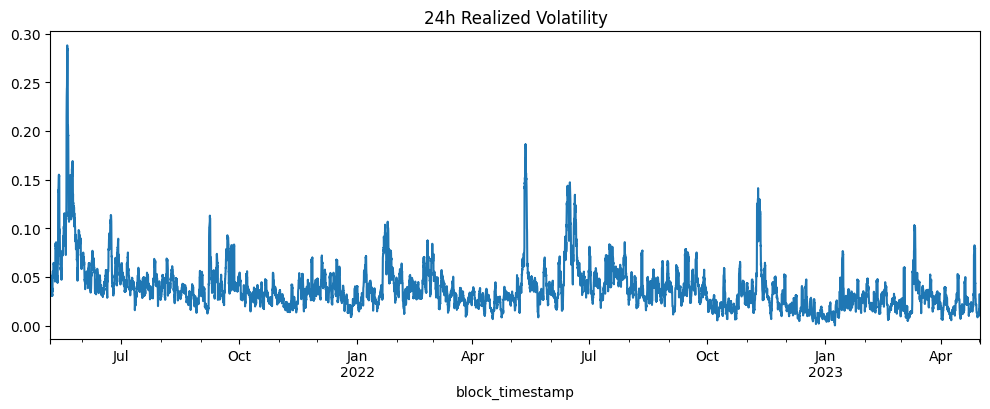

In [42]:
# 1) Volatility over time
hourly_swaps["rv_24h"].plot(figsize=(12,4))
plt.title("24h Realized Volatility")
plt.savefig('../../figures/regime-class/24hRealizedVol.png') 
plt.show()

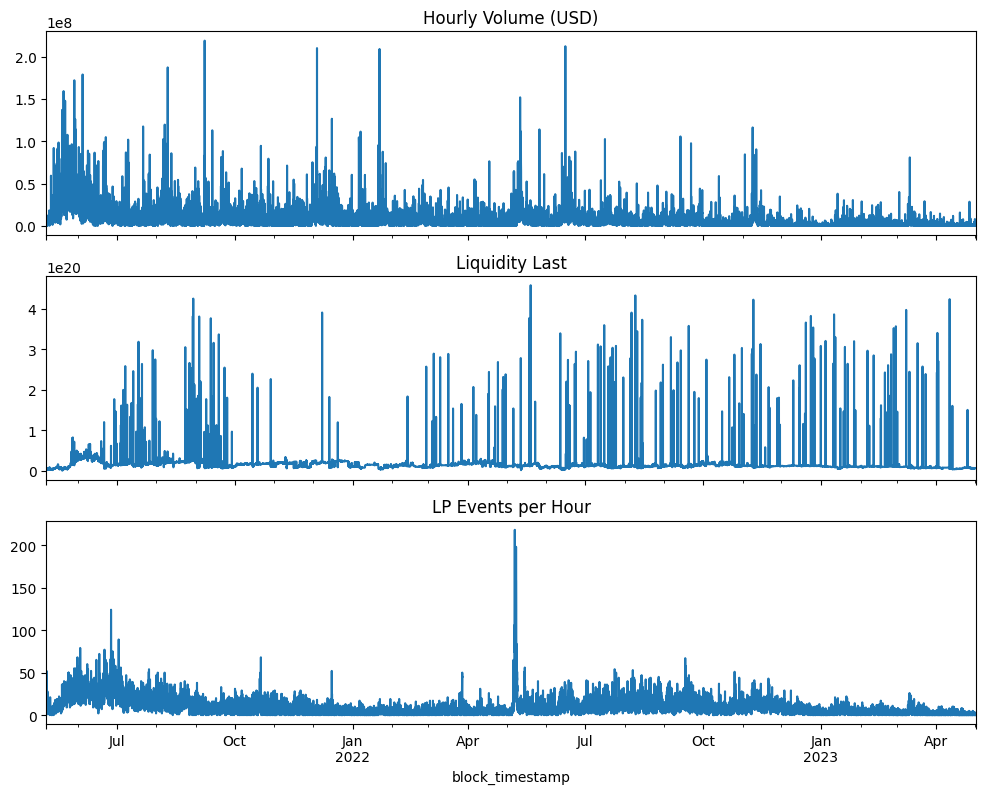

In [43]:
# 2) Volume & liquidity
fig, axes = plt.subplots(3, 1, figsize=(12,9), sharex=True)
hourly_swaps["volume_usd_1h"].plot(ax=axes[0])
axes[0].set_title("Hourly Volume (USD)")

hourly_swaps["liquidity_last"].plot(ax=axes[1])
axes[1].set_title("Liquidity Last")

hourly_swaps["lp_event_count"].plot(ax=axes[2])
axes[2].set_title("LP Events per Hour")
plt.savefig('../../figures/regime-class/hourlyVol_LiquidityLast_LPEvents.png') 
plt.show()

### Simple Correlations

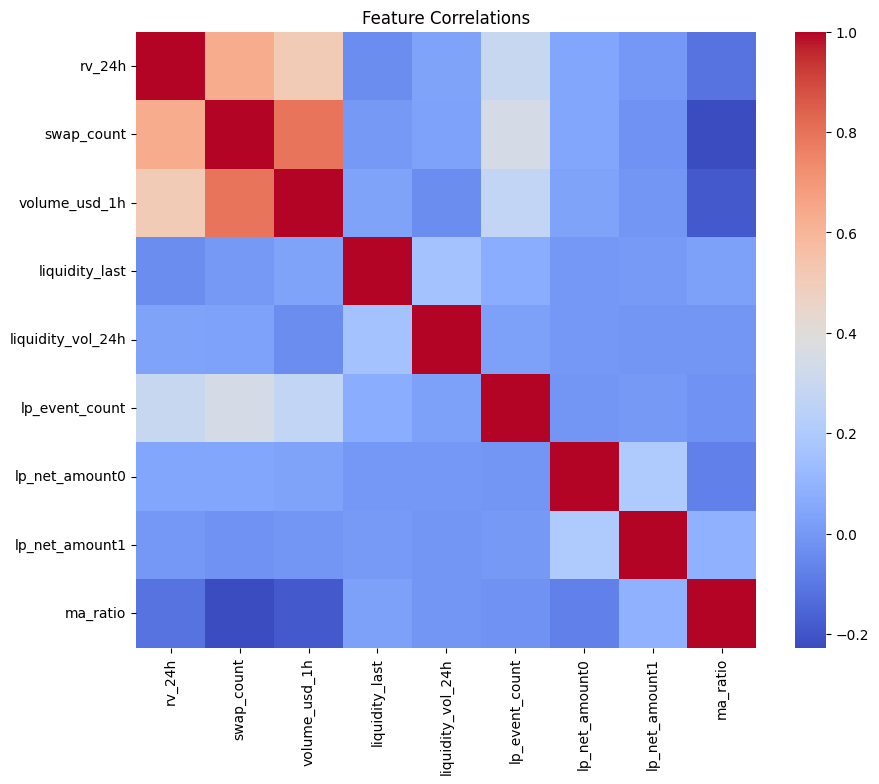

In [44]:
feature_cols = [
    "rv_24h", "swap_count", "volume_usd_1h",
    "liquidity_last", "liquidity_vol_24h",
    "lp_event_count", "lp_net_amount0", "lp_net_amount1",
    "ma_ratio"
]

plt.figure(figsize=(10,8))
sns.heatmap(hourly_swaps[feature_cols].corr(), annot=False, cmap="coolwarm")
plt.title("Feature Correlations")
plt.savefig('../../figures/regime-class/corrMatrix.png') 
plt.show()

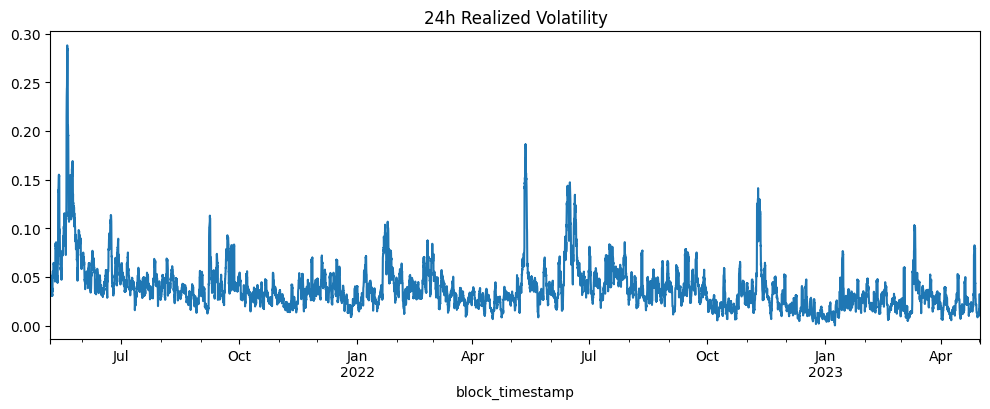

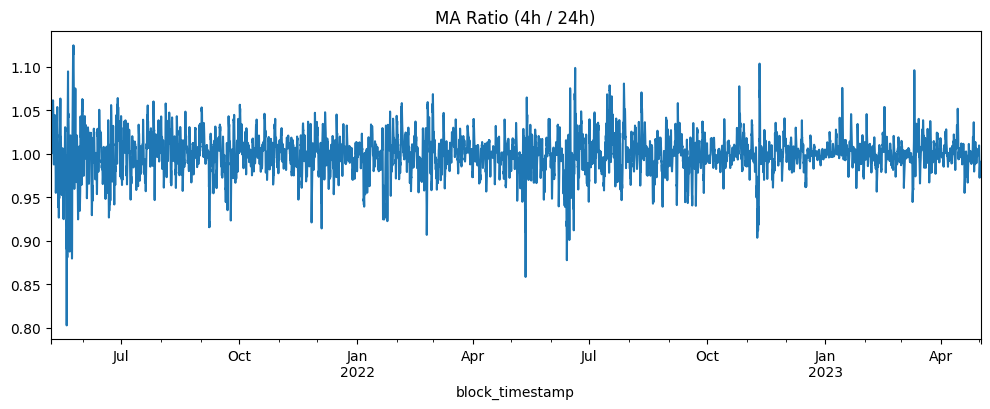

In [45]:
hourly_swaps["rv_24h"].plot(figsize=(12,4))
plt.title("24h Realized Volatility")
plt.show()

hourly_swaps["ma_ratio"].plot(figsize=(12,4))
plt.title("MA Ratio (4h / 24h)")
plt.savefig('../../figures/regime-class/MA_RealizedVol.png') 
plt.show()

<Axes: >

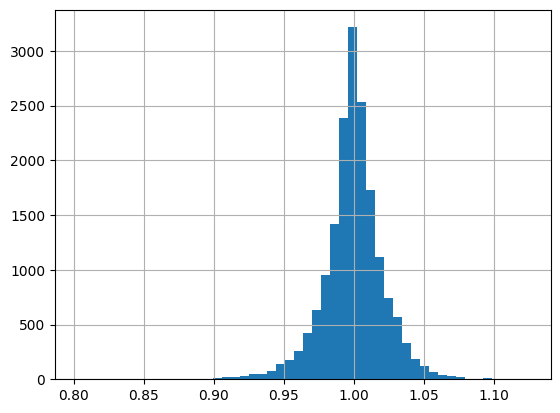

In [46]:
hourly_swaps["ma_ratio"].describe()
hourly_swaps["ma_ratio"].hist(bins=50)

### Now lets scale the features

In [47]:
from sklearn.preprocessing import StandardScaler

feature_cols = [
    "rv_24h",
    "ma_ratio",
    "volume_usd_1h",
    "liquidity_last",
    "liquidity_vol_24h",
    "lp_event_count",
]

X = hourly_swaps[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### Run da Kmeans

In [48]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2, 7)
inertias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))


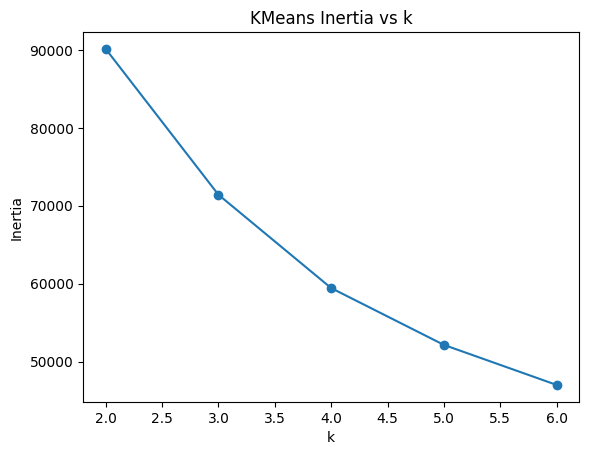

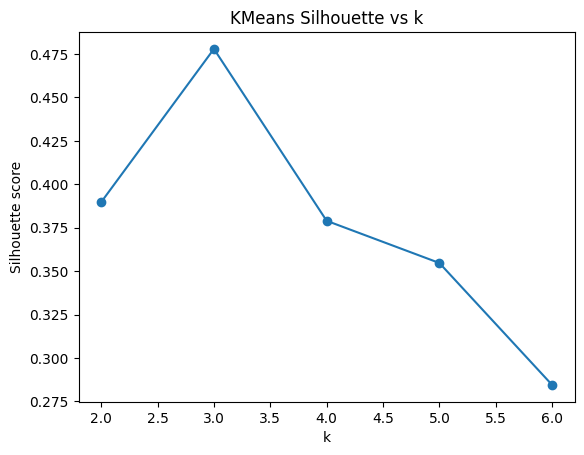

In [49]:
plt.figure()
plt.plot(ks, inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("KMeans Inertia vs k")
plt.savefig('../../figures/regime-class/KMeansInertiavsK.png') 
plt.show()

plt.figure()
plt.plot(ks, silhouettes, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("KMeans Silhouette vs k")
plt.savefig('../../figures/regime-class/KMeansSilhvsK.png') 
plt.show()


### Interpretation
- Based off the maximum at k=3, it looks like 3 clusters may be the best bet

In [50]:
best_k = 3

km = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
labels = km.fit_predict(X_scaled)

hourly_swaps["regime_kmeans"] = labels

In [51]:
feature_cols = ["rv_24h", "ma_ratio", "volume_usd_1h",
                "liquidity_last", "liquidity_vol_24h", "lp_event_count"]

hourly_swaps.groupby("regime_kmeans")[feature_cols].mean()

,rv_24h,ma_ratio,volume_usd_1h,liquidity_last,liquidity_vol_24h,lp_event_count
regime_kmeans,,,,,,
0,0.033588,1.001813,5036146.016632,1.390021e+19,1.004683,7.483837
1,0.077119,0.985072,29384875.058052,1.609081e+19,1.034028,23.921432
2,0.035480,1.000344,6749604.428509,2.415760e+20,4.687479,11.989071


Interesting, it looks like the regimes are split as:
- 0: calm
- 1: High vol
- 2: deep liquidity

In [52]:
regime_labels = {
    0: "normal_calm",
    1: "high_vol_breakout",
    2: "deep_liquidity_reconfig",
}
hourly_swaps["regime_label"] = hourly_swaps["regime_kmeans"].map(regime_labels)

### Lets compute future returns using the regimes

In [53]:
hourly_swaps["fwd_ret_4h"] = hourly_swaps["log_price"].shift(-4) - hourly_swaps["log_price"]
hourly_swaps.groupby("regime_label")["fwd_ret_4h"].agg(["mean","std","count"])

,mean,std,count
regime_label,,,
deep_liquidity_reconfig,-0.001723,0.024031,183
high_vol_breakout,-0.000246,0.032896,2151
normal_calm,-0.000112,0.016054,15061


- Based off these results, it looks like these regimes may be more useful for sizing risk as opposed to determining a clear trading signal.

### Lets test ARI

In [54]:
from sklearn.metrics import adjusted_rand_score

n_runs = 10
labels_list = []

for seed in range(n_runs):
    km = KMeans(n_clusters=3, random_state=seed, n_init="auto")
    labels_list.append(km.fit_predict(X_scaled))

aris = []
for i in range(n_runs):
    for j in range(i+1, n_runs):
        aris.append(adjusted_rand_score(labels_list[i], labels_list[j]))

np.mean(aris), np.std(aris)

(0.7533077271057336, 0.22424220451148114)

### PCA

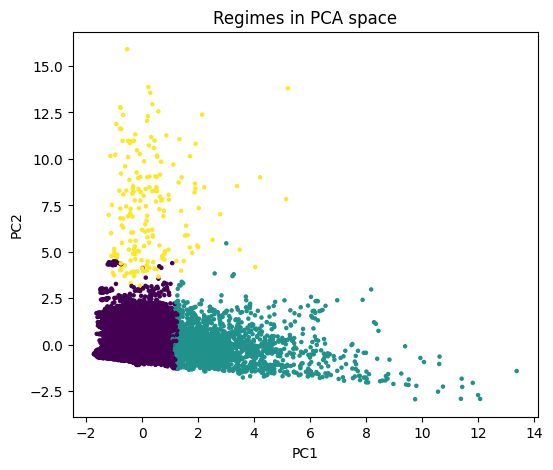

In [55]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

hourly_swaps["pc1"] = X_pca[:, 0]
hourly_swaps["pc2"] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(6, 5))
scatter = ax.scatter(
    hourly_swaps["pc1"],
    hourly_swaps["pc2"],
    c=hourly_swaps["regime_kmeans"],
    s=5,
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Regimes in PCA space")
plt.savefig('../../figures/regime-class/RegimesInPCA.png') 
plt.show()

In [56]:
pca.explained_variance_ratio_

array([0.29643037, 0.19532506])

### Lets get some visuals going

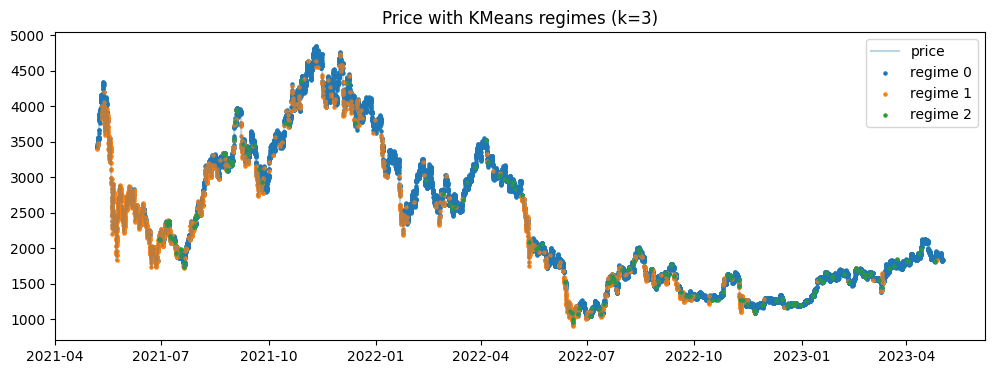

In [57]:
color_map = {0: "tab:blue", 1: "tab:orange", 2: "tab:green"}

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hourly_swaps.index, hourly_swaps["price_close"], alpha=0.3, label="price")

for k, grp in hourly_swaps.groupby("regime_kmeans"):
    ax.scatter(
        grp.index,
        grp["price_close"],
        s=5,
        color=color_map[k],
        label=f"regime {k}",
    )

ax.set_title("Price with KMeans regimes (k=3)")
ax.legend()
plt.savefig("../../figures/regime-class/PriceWithKMeansRegimes.png")
plt.show()

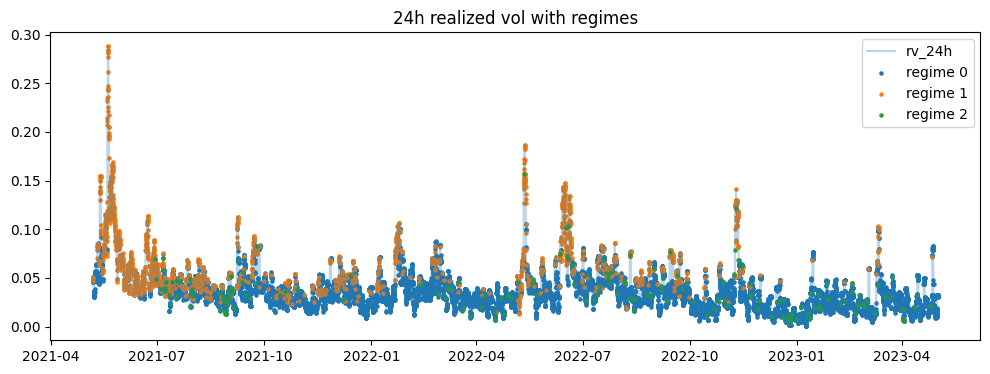

In [58]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hourly_swaps.index, hourly_swaps["rv_24h"], alpha=0.3, label="rv_24h")

for k, grp in hourly_swaps.groupby("regime_kmeans"):
    ax.scatter(
        grp.index,
        grp["rv_24h"],
        s=5,
        color=color_map[k],
        label=f"regime {k}",
    )

ax.set_title("24h realized vol with regimes")
ax.legend()
plt.savefig("../../figures/regime-class/24hRealizedVolWithRegimes.png")
plt.show()

### Testing the significance of model for risk sizing

In [59]:
import pandas as pd
import statsmodels.api as sm

# future vol
hourly_swaps["rv_24h_fwd"] = hourly_swaps["rv_24h"].shift(-24)

regime_dummies = pd.get_dummies(
    hourly_swaps["regime_kmeans"],
    prefix="regime",
    drop_first=True
).astype(float)

data = pd.concat(
    [hourly_swaps["rv_24h_fwd"], hourly_swaps["rv_24h"], regime_dummies],
    axis=1
).dropna()

y = data["rv_24h_fwd"].astype(float)
X = data[["rv_24h"] + list(regime_dummies.columns)].astype(float)
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             rv_24h_fwd   R-squared:                       0.434
Model:                            OLS   Adj. R-squared:                  0.434
Method:                 Least Squares   F-statistic:                     4433.
Date:                Sun, 23 Nov 2025   Prob (F-statistic):               0.00
Time:                        18:22:36   Log-Likelihood:                 44734.
No. Observations:               17375   AIC:                        -8.946e+04
Df Residuals:                   17371   BIC:                        -8.943e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0154      0.000     54.851      0.0

In [60]:
X0 = sm.add_constant(data[["rv_24h"]].astype(float))
m0 = sm.OLS(y, X0).fit()
print(m0.summary())

                            OLS Regression Results                            
Dep. Variable:             rv_24h_fwd   R-squared:                       0.423
Model:                            OLS   Adj. R-squared:                  0.423
Method:                 Least Squares   F-statistic:                 1.272e+04
Date:                Sun, 23 Nov 2025   Prob (F-statistic):               0.00
Time:                        18:22:36   Log-Likelihood:                 44567.
No. Observations:               17375   AIC:                        -8.913e+04
Df Residuals:                   17373   BIC:                        -8.911e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0136      0.000     51.329      0.0

### Comparing the baseline model without regimes to regimes:
- Today’s 24h vol explains most of tomorrow’s vol
- Knowing that we are in the high-vol breakout regime tells you that tomorrow’s vol will be a bit higher than you’d predict from rv_24h alone.
- The deep-liquidity regime doesn’t change future vol much once rv_24h is known.

In [62]:
hourly_swaps.head()

,price_close,price_open,price_high,price_low,swap_count,volume_usd_1h,avg_trade_size_usd,liquidity_last,liquidity_mean,liquidity_min,...,lp_burn_amount1,lp_net_amount0,lp_net_amount1,lp_event_count,regime_kmeans,regime_label,fwd_ret_4h,pc1,pc2,rv_24h_fwd
block_timestamp,,,,,,,,,,,,,,,,,,,,,
2021-05-07 01:00:00,3468.342720,3510.103946,3510.103946,3468.342720,28,3678211.14764,131364.683844,4.354625e+18,4.372535e+18,4.353786e+18,...,3612169409685928960.0,76649229911.0,12203572727552012288.0,14,0,normal_calm,-0.016612,0.173537,-0.518672,0.033777
2021-05-07 02:00:00,3419.408290,3459.052547,3462.691431,3419.408290,29,4290266.122388,147940.211117,4.078585e+18,4.300661e+18,4.070355e+18,...,123754837112743504.0,50981615882.0,17245043979514523648.0,24,0,normal_calm,0.004341,0.743695,-0.424080,0.030696
2021-05-07 03:00:00,3424.902830,3427.146466,3430.488601,3408.659436,33,5247964.336923,159029.222331,4.290646e+18,4.198945e+18,4.078625e+18,...,6885065486038511616.0,130446312022.0,51800385245940367360.0,21,0,normal_calm,0.004650,0.696765,-0.501762,0.030663
2021-05-07 04:00:00,3402.294308,3423.113110,3423.113110,3383.607072,31,6141030.994088,198097.774003,6.151794e+18,4.672352e+18,2.853843e+18,...,808744667522363949056.0,4139949653867.0,772519321253879087104.0,28,1,high_vol_breakout,0.006608,1.120707,-0.423873,0.031715
2021-05-07 05:00:00,3411.201925,3406.405109,3411.213633,3405.644716,26,1797129.634275,69120.370549,6.211178e+18,6.180953e+18,6.151794e+18,...,309591493679319552.0,265152691187.0,91405340427256119296.0,27,0,normal_calm,0.011947,0.912905,-0.441400,0.031995


In [64]:
hourly_swaps.tail()

,price_close,price_open,price_high,price_low,swap_count,volume_usd_1h,avg_trade_size_usd,liquidity_last,liquidity_mean,liquidity_min,...,lp_burn_amount1,lp_net_amount0,lp_net_amount1,lp_event_count,regime_kmeans,regime_label,fwd_ret_4h,pc1,pc2,rv_24h_fwd
block_timestamp,,,,,,,,,,,,,,,,,,,,,
2023-05-01 19:00:00,1815.871921,1835.658830,1835.658830,1815.087506,21,4441349.888475,211492.851832,7.167682e+18,7.140416e+18,7.092948e+18,...,9218130725748033536.0,93884419789.0,490781869273575325696.0,2,0,normal_calm,0.006679,-0.582552,-0.728656,NaN
2023-05-01 20:00:00,1814.042525,1816.212250,1816.360450,1813.806640,9,552201.07247,61355.674719,7.167682e+18,7.167682e+18,7.167682e+18,...,0.0,0.0,0.0,0,0,normal_calm,NaN,-0.862072,-0.772734,NaN
2023-05-01 21:00:00,1822.615887,1813.987141,1822.615887,1813.849891,20,1508534.67092,75426.733546,7.220734e+18,7.170335e+18,7.167682e+18,...,0.0,0.0,0.0,0,0,normal_calm,NaN,-0.804627,-0.779992,NaN
2023-05-01 22:00:00,1827.804953,1822.669605,1827.804953,1822.669605,8,878593.961607,109824.245201,7.220734e+18,7.220734e+18,7.220734e+18,...,0.0,0.0,0.0,0,0,normal_calm,NaN,-0.834348,-0.774921,NaN
2023-05-01 23:00:00,1828.041084,1828.041084,1828.041084,1828.041084,1,39941.287965,39941.287965,7.220734e+18,7.220734e+18,7.220734e+18,...,0.0,0.0,0.0,0,0,normal_calm,NaN,-0.932592,-0.747644,NaN


In [66]:
hourly_swaps.shape

(17399, 36)